# **Feature Engineering for the Suicidality Dataset**
The dataset, in its raw form, contains only the title and the post. This may be enough for more complex algorithms, but insufficient for tradition ML algorithms. With that, we need to derive more features that can help our models in their classification task

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn
import re
import emoji

from feature_engineering import \
extract_case_features, \
extract_word_features, \
extract_emoji_features, \
extract_emoticon_features, \
extract_all_features

%matplotlib inline
%load_ext autoreload
%autoreload 2

In [2]:
df = pd.read_csv("cleaned_suicidality_dataset_revised.csv", index_col=0)

df.head()

,title,post,label,has_post,text,text_cleaned,sub_metal_health_count,sub_dark_count,sub_support_count,sub_total_count
0,I'm looking for a girl I've met at the Polish ...,I've tried Polish spotted pages but I guess sh...,Non-Suicidal,1,I'm looking for a girl I've met at the Polish ...,I'm looking for a girl I've met at the Polish ...,0,0,0,0
1,I got a guy kicked off a domestic flight today.,I was in a forward row as we were boarding for...,Non-Suicidal,1,I got a guy kicked off a domestic flight today...,I got a guy kicked off a domestic flight today...,0,0,0,0
2,"My youngest got in school suspension, I’m so p...",So according to witness testimonies a boy grab...,Non-Suicidal,1,"My youngest got in school suspension, I’m so p...","My youngest got in school suspension, I’m so p...",0,0,0,0
3,"I'm a cashier who switched from ""sir/mam"" to ""...","So as said in the title, I'm a cashier (well, ...",Non-Suicidal,1,"I'm a cashier who switched from ""sir/mam"" to ""...","I'm a cashier who switched from ""sir/mam"" to ""...",0,0,0,0
4,My whole class complimented me and didn’t real...,"Today in class, we were doing this activity ca...",Non-Suicidal,1,My whole class complimented me and didn’t real...,My whole class complimented me and didn’t real...,0,0,0,0


For our task, we ideally want to know the emotion displayed in the text. Thus, a good feature will be one that reflects this. Most redditors show their emotion through their text in various ways:
- **Structure** (Using uppercase and expressive punctuations (e.g., !!!, ???, ...))
- **Reflecting words** (Words pertaining to depression, happiness, anger, etc.)
- **Imagery** (Emojis and Emoticons)
- **Context**

Understanding emotion through context can be difficult when dealing with text word for word (i.e., TF-IDF), however, encoding procedures using a semantic space may prove more effective.

Our feature engineering can be subject to changes given the error analysis for our models, since the models heavily rely on the features we provide.  With this in mind, we will encapsulate each feature derivation in functions in a separate module called `feature_engineering.py`

## Uppercase Features
People often display strong emotions by using uppercase typing. Our feature for this makes use of its count and ratio to other words in the instance. The `extract_case_features` helps us achieve this.

In [3]:
df["text_cleaned"].head().iloc[0]

"I'm looking for a girl I've met at the Polish airport to thank her properly! I've tried Polish spotted pages but I guess she isn't there. But I know she's active on this sub so... WHY THE HELL NOT? If you see this - you don't need to let me know. Just read it. I just want to thank you for not being indifferent. 2 weeks ago I was in a very bad place. My gf broke up with me just before I got into the plane and I landed just to find out my luggage got lost and like the last idiot I had there my cards and money. And I don't know Polish language. Like a real, adult man, I just sat there and cried like a baby, exhausted after very long trip. That Polish girl came already holding a cup with hot chocolate for me, asking if she could help in any way. We talked, she helped me with the luggage, helped me with the directions to my hotel and gave me money to get there. And we started talking about random things (like reddit) and for that I'm very thankful, you distracted me. I can't express how gr

In [4]:
df["text_cleaned"].map(extract_case_features).head().iloc[0]

(4, 0.017391304347826087)

We can see this returns two things, the first is the count of uppercase words, the second is the ratio of the uppercase words to non-uppercase words. These features tell us how often uppercase words were used in the post potentially indicating strong emotions.

We can also view the distribution of uppercase words in our dataset through this.

In [5]:
features = pd.DataFrame()
features["upper_count"], features["upper_ratio"] = zip(*df["text_cleaned"].map(extract_case_features))
features = pd.concat([features, df["label"]], axis=1)

uppercase_per_label = features.groupby("label").agg({"upper_count": "sum", "upper_ratio": "mean"})
uppercase_per_label

,upper_count,upper_ratio
label,,
Non-Suicidal,7161,0.009066
Suicidal,8185,0.008691


Text(0.5, 0.98, 'Uppercase_count and Ratio per Label')

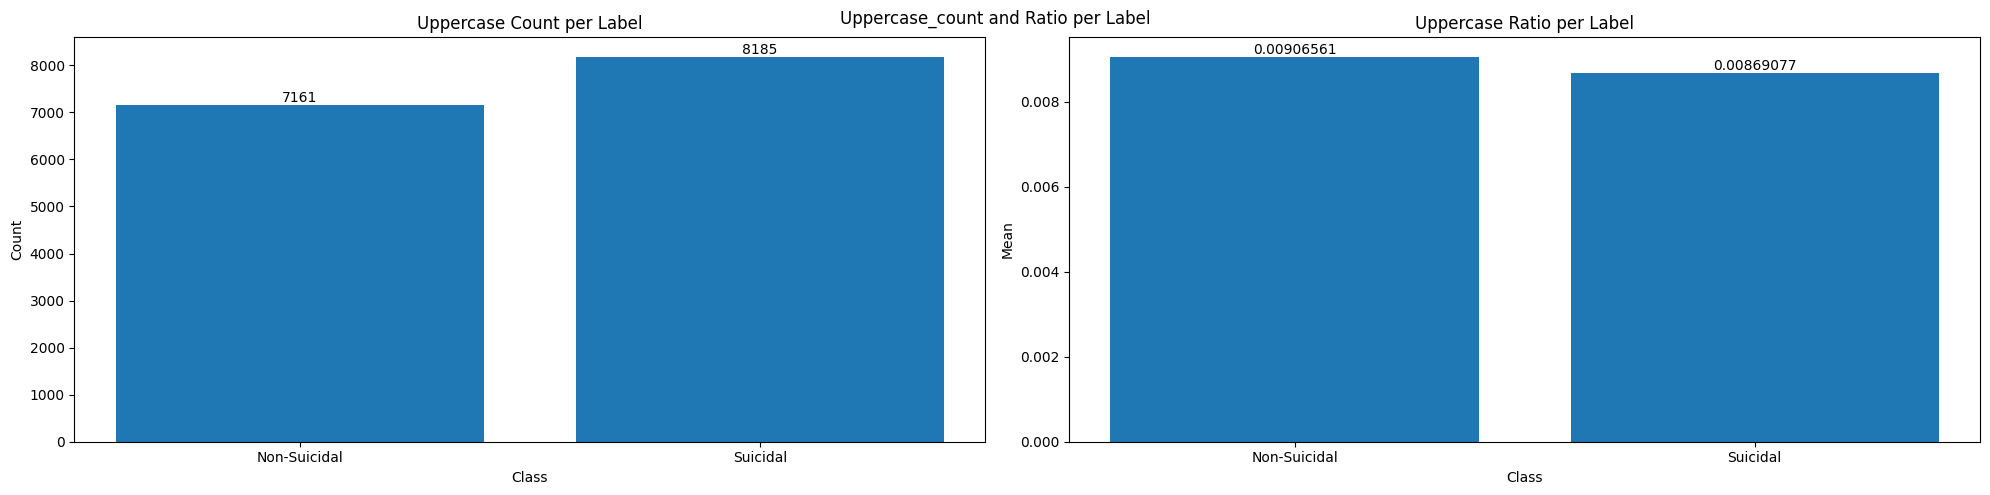

In [6]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(20, 5))

count_bars = ax[0].bar(x=uppercase_per_label["upper_count"].index, height=uppercase_per_label["upper_count"])
ax[0].bar_label(count_bars)
ax[0].set_title("Uppercase Count per Label")
ax[0].set_xlabel("Class")
ax[0].set_ylabel("Count")

ratio_bars = ax[1].bar(x=uppercase_per_label["upper_ratio"].index, height=uppercase_per_label["upper_ratio"])
ax[1].bar_label(ratio_bars)
ax[1].set_title("Uppercase Ratio per Label")
ax[1].set_xlabel("Class")
ax[1].set_ylabel("Mean")

fig.tight_layout()
fig.suptitle("Uppercase_count and Ratio per Label")

Non-suicidal posts have less uppercase word counts, although their word ratio are similar on average.  We keep those elements since they matter in conveying emotion. However, since it may cause overhead for traditional ml models, we will create a separate column with the text all lowercase, but we will retain the counts and ratios for reference. For deeper models like neural networks, we retain them.

## Punctuation Features
We will look into particularly exclamation (!) and interrogative punctuations (?). Strong emotions are often depicted with exclamation points. Redditors often ask questions or seek advice. Whether more or less punctuations depict likely suicidal people is a pattern the models will learn.

In [7]:
suicidal = df[df["label"] == "Suicidal"]
non_suicidal = df[df["label"] == "Non-Suicidal"]

In [8]:
punctuation_count_suicidal = suicidal["text_cleaned"].str.count(r"\?|!")
punctuation_count_suicidal.describe()

count    7275.000000
mean        0.821306
std         3.076419
min         0.000000
25%         0.000000
50%         0.000000
75%         1.000000
max       155.000000
Name: text_cleaned, dtype: float64

In [9]:
punctuation_count_nonsuicidal = non_suicidal["text_cleaned"].str.count(r"\?|!")
punctuation_count_nonsuicidal.describe()

count    8201.000000
mean        1.863919
std         9.198556
min         0.000000
25%         0.000000
50%         1.000000
75%         2.000000
max       502.000000
Name: text_cleaned, dtype: float64

Punctuations are used sparingly, however there seem to be some outliers in poth classes.

## Reflecting Words Features
The biggest indicator of emotion is evidently in the words they choose. Given our task of classifying suicidality, the words we will keep track of allude to sentiments of depression and sadness.

To ground the features listed here, we have consulted various sources namely,

| Feature | Research Basis |
|---|---|
| **First-person pronouns** | Rude, Gortner & Pennebaker (2004) — elevated "I-talk" reflects self-focused attention in depression |
| **Absolutist words** | Al-Mosaiwi & Johnstone (2018) — absolutist language is highest in suicidal ideation, more specific than negative emotion words |
| **Negative emotion words** | LIWC Negemo category (Pennebaker et al.) — standard lexicon for computational detection of emotional distress |
| **Death-related words** | Coppersmith, Dredze & Harman (2014) + LIWC Death category — significantly elevated in at-risk individuals |
| **Past tense markers** | Coppersmith et al. (2014) — increased past tense usage signals disconnection from the present and ruminative thinking |


In [10]:
# Pronoun features
first_person_singular = r"\b(I(?:'|')?(?:m|ve|ll|d)?|me|my|mine|myself)\b"
first_person_plural = r"\b(we(?:'|')?(?:re|ve|ll|d)?|us|our|ours|ourselves)\b"

# Absolutist words (Obtained from paper)
absolutist = r"\b(absolutely|all|always|complete|completely|constant|constantly|definitely|entire|entirely|ever|every|everyone|everything|full|must|never|nothing|totally|whole)\b"

# Negative emotion 
negative = r"\b(sad|miserable|unhappy|depressed|hopeless|worthless|alone|lonely|hurt|pain|suffer|cry|tears|awful|terrible|horrible)\b"

# Death-related 
death = r"\b(death|die|dead|dying|suicide|suicidal|kill|killed|killing|end|ending|struggle|struggling)\b"

# Past tense 
past_tense = r"\b(was|were|had|did|been)\b" # Shows reminiscing/reflection

The `extract_word_features` function allows to count words that match these regex expression.

In [11]:
features = extract_word_features(df["text_cleaned"])

features

,first_person_singular,first_person_plural,absolutist_count,negative_emotion,death_related,past_tense
0,27,2,0,0,0,3
1,15,3,0,0,0,5
2,4,2,2,0,0,0
3,55,4,9,0,0,2
4,15,3,2,0,0,4
...,...,...,...,...,...,...
15471,5,0,1,1,1,0
15472,19,0,7,0,0,0
15473,22,0,1,2,5,2
15474,38,0,7,3,0,0


This gives us an idea how prominent dark emotion words are in each instance.

## Emojis/Emoticons Feature  
Redditors use emojis or emoticons to further drive emotions in their posts. We will use the `extract_emoticons_features` and `extract_emojis_features` for this. The `extract_emojis_features` make use of the `emoji` library to identify the different emojis in the posts.

We first view the existence of emojis/emoticons in the posts

In [12]:
df["text_cleaned"].map(lambda x : list(emoji.analyze(x))).sum()

[Token(chars='🙃', value=EmojiMatch(🙃, 486:487)),
 Token(chars='😂', value=EmojiMatch(😂, 691:692)),
 Token(chars='🥳', value=EmojiMatch(🥳, 26:27)),
 Token(chars='🎉', value=EmojiMatch(🎉, 121:122)),
 Token(chars='😂', value=EmojiMatch(😂, 1739:1740)),
 Token(chars='😂', value=EmojiMatch(😂, 1817:1818)),
 Token(chars='😊', value=EmojiMatch(😊, 1108:1109)),
 Token(chars='💜', value=EmojiMatch(💜, 273:274)),
 Token(chars='✌️', value=EmojiMatch(✌️, 274:276)),
 Token(chars='💜', value=EmojiMatch(💜, 1863:1864)),
 Token(chars='✌️', value=EmojiMatch(✌️, 1864:1866)),
 Token(chars='😂', value=EmojiMatch(😂, 1331:1332)),
 Token(chars='😭', value=EmojiMatch(😭, 1359:1360)),
 Token(chars='🥩', value=EmojiMatch(🥩, 3406:3407)),
 Token(chars='😭', value=EmojiMatch(😭, 156:157)),
 Token(chars='😭', value=EmojiMatch(😭, 157:158)),
 Token(chars='😄', value=EmojiMatch(😄, 806:807)),
 Token(chars='🙃', value=EmojiMatch(🙃, 905:906)),
 Token(chars='💀', value=EmojiMatch(💀, 2575:2576)),
 Token(chars='🥲', value=EmojiMatch(🥲, 846:847)),


In here, we can confirm the existence of emojis. We then check for the existence of emoticons. We will use positive emoticons as an example.

In [13]:
positive_pattern = r"(?:^|\s)(:\)|:D|;\)|=\)|:-\)|:\]|=D|:>|8\))(?=\s|$)"

df["text_cleaned"].map(lambda x : len(re.findall(positive_pattern, x))).sum()

np.int64(694)

Using the functions mentioned earlier, we will return counts for the each category of emoji and emoticon.

In [14]:
df["text_cleaned"].map(extract_emoji_features)

0        (0, 0, 0, 0)
1        (0, 0, 0, 0)
2        (0, 0, 0, 0)
3        (0, 0, 0, 0)
4        (0, 0, 0, 0)
             ...     
15471    (0, 0, 0, 0)
15472    (0, 0, 0, 0)
15473    (0, 0, 0, 0)
15474    (0, 0, 0, 0)
15475    (0, 0, 0, 0)
Name: text_cleaned, Length: 15476, dtype: object

In [15]:
df["text_cleaned"].map(extract_emoticon_features)

0        (0, 0, 0, 0, 0, 0)
1        (0, 0, 0, 0, 0, 0)
2        (0, 0, 0, 0, 0, 0)
3        (1, 0, 0, 0, 0, 0)
4        (1, 0, 0, 0, 0, 0)
                ...        
15471    (0, 0, 0, 0, 0, 0)
15472    (0, 0, 0, 0, 0, 0)
15473    (0, 0, 0, 0, 0, 0)
15474    (0, 0, 0, 0, 0, 0)
15475    (0, 0, 0, 0, 0, 0)
Name: text_cleaned, Length: 15476, dtype: object

## Context

This will be difficult to map and it depends on the encoding. For this, we will let the models recognize the patterns that might suggest it.

Given what we have seen, we will make a unified clean_reddit_post function and put it in new column.

## Features

In [16]:
df.head()

,title,post,label,has_post,text,text_cleaned,sub_metal_health_count,sub_dark_count,sub_support_count,sub_total_count
0,I'm looking for a girl I've met at the Polish ...,I've tried Polish spotted pages but I guess sh...,Non-Suicidal,1,I'm looking for a girl I've met at the Polish ...,I'm looking for a girl I've met at the Polish ...,0,0,0,0
1,I got a guy kicked off a domestic flight today.,I was in a forward row as we were boarding for...,Non-Suicidal,1,I got a guy kicked off a domestic flight today...,I got a guy kicked off a domestic flight today...,0,0,0,0
2,"My youngest got in school suspension, I’m so p...",So according to witness testimonies a boy grab...,Non-Suicidal,1,"My youngest got in school suspension, I’m so p...","My youngest got in school suspension, I’m so p...",0,0,0,0
3,"I'm a cashier who switched from ""sir/mam"" to ""...","So as said in the title, I'm a cashier (well, ...",Non-Suicidal,1,"I'm a cashier who switched from ""sir/mam"" to ""...","I'm a cashier who switched from ""sir/mam"" to ""...",0,0,0,0
4,My whole class complimented me and didn’t real...,"Today in class, we were doing this activity ca...",Non-Suicidal,1,My whole class complimented me and didn’t real...,My whole class complimented me and didn’t real...,0,0,0,0


In [17]:
features = extract_all_features(df["text_cleaned"])

features.head()

Extracting ASCII emoticon features...
Extracting Unicode emoji features...


,first_person_singular,first_person_plural,absolutist_count,negative_emotion,death_related,past_tense,exclamation_count,question_count,upper_word_count,upper_word_ratio,emoticon_positive,emoticon_negative,emoticon_crying,emoticon_neutral,emoticon_heart,emoticon_broken_heart,emoji_negative,emoji_positive,emoji_crisis,emoji_implicit_distress
0,27,2,0,0,0,3,1,1,4,0.017391,0,0,0,0,0,0,0,0,0,0
1,15,3,0,0,0,5,0,1,1,0.004950,0,0,0,0,0,0,0,0,0,0
2,4,2,2,0,0,0,0,0,4,0.050000,0,0,0,0,0,0,0,0,0,0
3,55,4,9,0,0,2,0,0,0,0.000000,1,0,0,0,0,0,0,0,0,0
4,15,3,2,0,0,4,0,1,1,0.005435,1,0,0,0,0,0,0,0,0,0


In [18]:
df = pd.concat([df, features], axis=1)
df.to_csv("suicidality_dataset_w_features.csv")